In [18]:
# If your environment already has these, you can skip running this cell.
%pip install -q transformers accelerate torch pandas tqdm

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Note: you may need to restart the kernel to use updated packages.


In [19]:
import os
import json
import math
import pandas as pd
import torch
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# ==== CONFIG ====
INPUT_CSV = "/home/ubuntu/TW_MultiLabel_SMP/datasets/4500_Posts_Annotations - Combined_Dataset.csv"
OUTPUT_CSV = "/home/ubuntu/TW_MultiLabel_SMP/Perplexity Files/MFT_r12/r12_final_with_MFT.csv"
MAPPING_JSON = "/home/ubuntu/TW_MultiLabel_SMP/Perplexity Files/MFT_r12/r12_mft_label_mapping.json"      # mapping file
PIVOT_CSV = "/home/ubuntu/TW_MultiLabel_SMP/Perplexity Files/MFT_r12/r12_mft_tag_pivot.csv"           # optional co-occurrence table

# Column names
TEXT_COL = "combined_text"   # we'll build this from title + body
TAGS_COL = "Tags"            # your human-corrected labels

# Model \+ inference params
MODEL_CANDIDATES = [
    "MMADS/MoralFoundationsClassifier",  # public, 10 virtues/vices
]
BATCH_SIZE = 16
MAX_LENGTH = 256
PROB_THRESHOLD = 0.50       # try 0.30–0.60 later if you want to sweep
SAVE_PROBS = True

device = "cuda" if torch.cuda.is_available() else "cpu"
device


'cpu'

In [20]:
# Load CSV
df = pd.read_csv(INPUT_CSV)

# Drop stray unnamed columns if present
df = df.loc[:, ~df.columns.str.contains("^Unnamed")].copy()

# Ensure title/body exist; if not, fallback gracefully
title_ok = "title" in df.columns
body_ok  = "body" in df.columns

if title_ok:
    df["title"] = df["title"].fillna("").astype(str).str.strip()
if body_ok:
    df["body"]  = df["body"].fillna("").astype(str).str.strip()

if title_ok and body_ok:
    df[TEXT_COL] = (df["title"] + " " + df["body"]).str.strip()
elif body_ok:
    df[TEXT_COL] = df["body"]
elif title_ok:
    df[TEXT_COL] = df["title"]
else:
    raise KeyError(f"No suitable text columns found. Available columns: {list(df.columns)}")

# Sanity check
print(df.shape)
df[[TEXT_COL, TAGS_COL]].head(3)


(4494, 6)


,combined_text,Tags
0,"Complications after abortion? Hi everyone, Ive...","Medical, Pregnancy, Mental Health"
1,Second MA abortion today and I'm absolutely te...,"Medical, Pregnancy, Mental Health"
2,Help needed/ live in Texas where abortion in b...,Medical


In [21]:
# Try to load a public Moral Foundations classifier
last_err = None
for name in MODEL_CANDIDATES:
    try:
        print(f"Trying model: {name}")
        tokenizer = AutoTokenizer.from_pretrained(name)
        model = AutoModelForSequenceClassification.from_pretrained(name)
        MODEL_NAME = name
        print(f"Loaded model: {MODEL_NAME}")
        break
    except Exception as e:
        print(f"Failed: {name} -> {e}")
        last_err = e

if 'model' not in globals():
    raise last_err

model.to(device)
model.eval()

# Label mapping from config (some models leave generic LABEL_0...)
id2label = model.config.id2label
label2id = model.config.label2id
mft_labels = [id2label[i] for i in range(len(id2label))]
print("Raw model labels (id order):", mft_labels)


Trying model: MMADS/MoralFoundationsClassifier
Loaded model: MMADS/MoralFoundationsClassifier
Raw model labels (id order): ['LABEL_0', 'LABEL_1', 'LABEL_2', 'LABEL_3', 'LABEL_4', 'LABEL_5', 'LABEL_6', 'LABEL_7', 'LABEL_8', 'LABEL_9']


In [22]:
@torch.no_grad()
def predict_mft_batch(text_list):
    enc = tokenizer(
        text_list,
        truncation=True,
        padding=True,
        max_length=MAX_LENGTH,
        return_tensors="pt"
    )
    enc = {k: v.to(device) for k, v in enc.items()}
    outputs = model(**enc)
    probs = torch.sigmoid(outputs.logits).detach().cpu().numpy()
    return probs  # shape: (batch, num_labels)

def probs_to_labels(prob_row, labels, threshold=PROB_THRESHOLD, ensure_top1=True):
    picked = [labels[i] for i, p in enumerate(prob_row) if p >= threshold]
    if ensure_top1 and not picked:
        import numpy as np
        picked = [labels[int(np.asarray(prob_row).argmax())]]
    return picked


In [23]:
all_probs = []
texts = df[TEXT_COL].fillna("").astype(str).tolist()

for i in tqdm(range(0, len(texts), BATCH_SIZE), total=math.ceil(len(texts)/BATCH_SIZE)):
    batch = texts[i:i+BATCH_SIZE]
    batch_probs = predict_mft_batch(batch)
    all_probs.extend(batch_probs)

num_labels = len(mft_labels)
assert all(len(row) == num_labels for row in all_probs), "Unexpected logits shape from the model."

# Convert to multi-label strings
mft_label_lists = [probs_to_labels(row, mft_labels, PROB_THRESHOLD) for row in all_probs]
mft_label_strs  = [", ".join(x) for x in mft_label_lists]

df["MFT_Labels"] = mft_label_strs

if SAVE_PROBS:
    def row_to_json(row):
        return json.dumps({mft_labels[i]: float(row[i]) for i in range(num_labels)}, ensure_ascii=False)
    df["MFT_Probs_JSON"] = [row_to_json(row) for row in all_probs]

df.head(5)


  0%|          | 0/281 [00:00<?, ?it/s]

,id,subreddit,title,body,Tags,combined_text,MFT_Labels,MFT_Probs_JSON
0,1ljxynj,abortion,Complications after abortion?,"Hi everyone, Ive read that abortions don’t cau...","Medical, Pregnancy, Mental Health","Complications after abortion? Hi everyone, Ive...",LABEL_1,"{""LABEL_0"": 0.003292871406301856, ""LABEL_1"": 0..."
1,1ljxtt8,abortion,Second MA abortion today and I'm absolutely te...,I'm having my second MA abortion today and I'm...,"Medical, Pregnancy, Mental Health",Second MA abortion today and I'm absolutely te...,LABEL_1,"{""LABEL_0"": 0.0021010502241551876, ""LABEL_1"": ..."
2,1ljwhkb,abortion,Help needed/ live in Texas where abortion in b...,Anyone know of a legit site to support women i...,Medical,Help needed/ live in Texas where abortion in b...,LABEL_0,"{""LABEL_0"": 0.9895903468132019, ""LABEL_1"": 0.0..."
3,1ljvy6u,abortion,medical abortion at 6 weeks,I’ll be doing my procedure on Friday and I got...,Medical,medical abortion at 6 weeks I’ll be doing my p...,LABEL_8,"{""LABEL_0"": 0.0028816494159400463, ""LABEL_1"": ..."
4,1ljv5k4,abortion,Idk what to feel about my decision after doing...,I just had medical abortion yesterday. I was a...,"Pregnancy, Mental Health",Idk what to feel about my decision after doing...,LABEL_0,"{""LABEL_0"": 0.9518358111381531, ""LABEL_1"": 0.0..."


In [24]:
# Auto-map LABEL_i -> meaningful moral names via simple probes
import numpy as np

# Candidate names (virtue/vice for the 5 foundations)
CANDIDATE_CLASS_NAMES = [
    "Care_Virtue", "Care_Vice",
    "Fairness_Virtue", "Fairness_Vice",
    "Loyalty_Virtue", "Loyalty_Vice",
    "Authority_Virtue", "Authority_Vice",
    "Sanctity_Virtue", "Sanctity_Vice",
]

PROBES = {
    "Care_Virtue": [
        "We should protect the vulnerable and reduce suffering.",
        "Kindness and compassion toward others matter most.",
    ],
    "Care_Vice": [
        "Hurting the weak and ignoring their pain is acceptable.",
        "Cruelty is fine; suffering is not my concern.",
    ],
    "Fairness_Virtue": [
        "Everyone deserves equal treatment and justice.",
        "We must be fair and stop cheating.",
    ],
    "Fairness_Vice": [
        "Cheating is fine if it benefits us.",
        "Unequal rules are acceptable when they help my side.",
    ],
    "Loyalty_Virtue": [
        "Stand by your group and never betray your team.",
        "We should be loyal to our community and kin.",
    ],
    "Loyalty_Vice": [
        "It is fine to betray your group for personal gain.",
        "Disloyalty to your own side is admirable.",
    ],
    "Authority_Virtue": [
        "Respecting tradition and legitimate authority is important.",
        "We should honor elders and follow rightful leaders.",
    ],
    "Authority_Vice": [
        "Subverting order and disrespecting leaders is good.",
        "Rebellion against rightful authority is a virtue.",
    ],
    "Sanctity_Virtue": [
        "Purity and cleanliness of body and soul should be protected.",
        "We must avoid degradation and keep what is sacred pure.",
    ],
    "Sanctity_Vice": [
        "Desecration and impurity are admirable.",
        "Defilement and degradation are good things.",
    ],
}

def avg_probs_for_texts(texts):
    p = predict_mft_batch(texts)
    return np.array(p).mean(axis=0)

assert len(mft_labels) == 10, f"Expected 10 labels; got {len(mft_labels)}. Adjust CANDIDATE_CLASS_NAMES/PROBES accordingly."

class2best_label = {}
for cname, probes in PROBES.items():
    avgp = avg_probs_for_texts(probes)
    class2best_label[cname] = int(avgp.argmax())

# Resolve collisions greedily
label2class = {}
for cname, idx in sorted(class2best_label.items(), key=lambda x: -x[1]):
    if idx not in label2class:
        label2class[idx] = cname
    else:
        # try alternate best
        avgp = avg_probs_for_texts(PROBES[cname])
        order = avgp.argsort()[::-1]
        chosen = None
        for alt in order:
            if int(alt) not in label2class:
                chosen = int(alt)
                break
        if chosen is None:
            chosen = idx
        label2class[chosen] = cname

LABELI_TO_NAME = { f"LABEL_{i}": label2class.get(i, f"UNKNOWN_{i}") for i in range(len(mft_labels)) }
NAME_TO_LABELI = { v: k for k, v in LABELI_TO_NAME.items() }

print("Auto-derived mapping (LABEL_i -> Moral_Name):")
for k,v in LABELI_TO_NAME.items():
    print(f"{k:>8}  ->  {v}")

# Save mapping
os.makedirs(os.path.dirname(MAPPING_JSON), exist_ok=True)
with open(MAPPING_JSON, "w") as f:
    json.dump(LABELI_TO_NAME, f, indent=2)
MAPPING_JSON


Auto-derived mapping (LABEL_i -> Moral_Name):
 LABEL_0  ->  Care_Virtue
 LABEL_1  ->  Care_Vice
 LABEL_2  ->  Fairness_Virtue
 LABEL_3  ->  Fairness_Vice
 LABEL_4  ->  Loyalty_Virtue
 LABEL_5  ->  Loyalty_Vice
 LABEL_6  ->  Authority_Virtue
 LABEL_7  ->  Authority_Vice
 LABEL_8  ->  Sanctity_Virtue
 LABEL_9  ->  Sanctity_Vice


'/home/ubuntu/TW_MultiLabel_SMP/Perplexity Files/MFT_r12/r12_mft_label_mapping.json'

In [26]:
def remap_label_string(s):
    parts = [p.strip() for p in s.split(",") if p.strip()]
    parts_new = [LABELI_TO_NAME.get(p, p) for p in parts]
    return ", ".join(parts_new)

df["MFT_Labels_Name"] = df["MFT_Labels"].fillna("").astype(str).apply(remap_label_string)

def first_label(s):
    parts = [p.strip() for p in s.split(",") if p.strip()]
    return parts[0] if parts else ""

df["MFT_First_Name"] = df["MFT_Labels_Name"].apply(first_label)

print("Top first moral labels (readable):")
print(df["MFT_First_Name"].value_counts().head(10))


Top first moral labels (readable):
MFT_First_Name
Care_Virtue         2403
Care_Vice            926
Authority_Virtue     543
Sanctity_Virtue      196
Loyalty_Virtue       188
Sanctity_Vice        108
Fairness_Virtue       75
Fairness_Vice         50
Authority_Vice         4
Loyalty_Vice           1
Name: count, dtype: int64


In [28]:
# Build co-occurrence table between your Tags and readable Moral labels
tmp = df.copy()
tmp["Tags_list"] = tmp[TAGS_COL].fillna("").astype(str).apply(lambda s: [t.strip() for t in s.split(",") if t.strip()])
tmp["MFT_list_name"] = tmp["MFT_Labels_Name"].fillna("").astype(str).apply(lambda s: [t.strip() for t in s.split(",") if t.strip()])

rows = []
for _, r in tmp.iterrows():
    for t in r["Tags_list"]:
        for m in r["MFT_list_name"]:
            rows.append((t, m))

co = pd.DataFrame(rows, columns=["Tag","Moral"])
pivot = co.pivot_table(index="Tag", columns="Moral", values="Tag", aggfunc="count", fill_value=0)
print(pivot.head(10))

# Save pivot and the main CSV
os.makedirs(os.path.dirname(OUTPUT_CSV), exist_ok=True)
df.to_csv(OUTPUT_CSV, index=False)
pivot.to_csv(PIVOT_CSV)

OUTPUT_CSV, PIVOT_CSV


Empty DataFrame
Columns: []
Index: [Abuse, Aggression, Discrimination, Medical, Mental Health, Not Applicable, Pregnancy, Sexual]


('/home/ubuntu/TW_MultiLabel_SMP/Perplexity Files/MFT_r12/r12_final_with_MFT.csv',
 '/home/ubuntu/TW_MultiLabel_SMP/Perplexity Files/MFT_r12/r12_mft_tag_pivot.csv')

In [29]:
# Rebuild labels at different thresholds from already-computed all_probs
import numpy as np

def labels_from_probs_with_threshold(all_probs, labels, thr):
    out = []
    for row in all_probs:
        inds = [i for i,p in enumerate(row) if p >= thr]
        if not inds:
            inds = [int(np.asarray(row).argmax())]
        names = []
        for i in inds:
            label_i = f"LABEL_{i}"
            names.append(LABELI_TO_NAME.get(label_i, label_i))
        out.append(", ".join(names))
    return out

for thr in [0.30, 0.40, 0.50, 0.60]:
    names_at_thr = labels_from_probs_with_threshold(all_probs, mft_labels, thr)
    firsts = pd.Series([s.split(",")[0].strip() if s else "" for s in names_at_thr])
    print(f"\n== Threshold {thr} (readable) ==")
    print(firsts.value_counts().head(10))



== Threshold 0.3 (readable) ==
Care_Virtue         2408
Care_Vice            932
Authority_Virtue     544
Sanctity_Virtue      195
Loyalty_Virtue       180
Sanctity_Vice        102
Fairness_Virtue       76
Fairness_Vice         52
Authority_Vice         4
Loyalty_Vice           1
Name: count, dtype: int64

== Threshold 0.4 (readable) ==
Care_Virtue         2407
Care_Vice            927
Authority_Virtue     546
Sanctity_Virtue      195
Loyalty_Virtue       184
Sanctity_Vice        104
Fairness_Virtue       76
Fairness_Vice         50
Authority_Vice         4
Loyalty_Vice           1
Name: count, dtype: int64

== Threshold 0.5 (readable) ==
Care_Virtue         2403
Care_Vice            926
Authority_Virtue     543
Sanctity_Virtue      196
Loyalty_Virtue       188
Sanctity_Vice        108
Fairness_Virtue       75
Fairness_Vice         50
Authority_Vice         4
Loyalty_Vice           1
Name: count, dtype: int64

== Threshold 0.6 (readable) ==
Care_Virtue         2396
Care_Vice          

In [30]:
# peek at how Tags is stored (string list? comma/pipeline? JSON?)
print("Total rows:", len(df))
print("\nSample raw Tags values:")
print(df["Tags"].head(10).to_list())

print("\nValue counts (top 20, raw):")
print(df["Tags"].value_counts(dropna=False).head(20))


Total rows: 4494

Sample raw Tags values:
['Medical, Pregnancy, Mental Health', 'Medical, Pregnancy, Mental Health', 'Medical', 'Medical', 'Pregnancy, Mental Health', 'Pregnancy, Sexual', 'Pregnancy, Mental Health, Medical', 'Medical, Pregnancy', 'Mental Health, Pregnancy, Medical', 'Pregnancy, Mental Health']

Value counts (top 20, raw):
Tags
Not Applicable                                  778
Abuse, Mental Health                            413
Abuse, Sexual, Mental Health                    395
Medical, Pregnancy, Mental Health               332
Pregnancy, Medical, Mental Health               321
Pregnancy, Mental Health                        290
Medical, Mental Health, Pregnancy               287
Mental Health, Pregnancy                        182
Pregnancy, Medical                              158
Medical, Pregnancy                              101
Abuse, Mental Health, Discrimination             84
Pregnancy                                        83
Abuse                         

In [40]:
import ast

# --- force morals into a true list ---
def to_list_morals(x):
    # handle real list
    if isinstance(x, list):
        return [s.strip() for s in x if str(s).strip()]
    s = str(x).strip()
    if not s:
        return []
    # handle "['Care_Virtue', 'Care_Vice']" style
    if (s.startswith("[") and s.endswith("]")) or (s.startswith("(") and s.endswith(")")):
        try:
            val = ast.literal_eval(s)
            if isinstance(val, (list, tuple)):
                return [str(v).strip() for v in val if str(v).strip()]
        except Exception:
            pass
    # fallback: comma-split "A, B, C"
    return [p.strip() for p in s.split(",") if p.strip()]

# --- force tags into a true list (from raw Tags every time) ---
KNOWN_TAGS = {
    "Abuse","Aggression","Discrimination","Medical",
    "Mental Health","Not Applicable","Pregnancy","Sexual"
}

def to_list_tags(s):
    s = str(s).replace("\xa0", " ").strip()
    parts = [p.strip() for p in s.split(",") if p.strip()]
    seen, out = set(), []
    for p in parts:
        if p in KNOWN_TAGS and p not in seen:
            out.append(p); seen.add(p)
    return out

# rebuild both columns deterministically
df["MFT_list_name"] = df["MFT_Labels_Name"].apply(to_list_morals)
df["Tags_list"]     = df["Tags"].apply(to_list_tags)

print("Rows:", len(df))
print("rows with >=1 moral:", sum(len(x)>0 for x in df["MFT_list_name"]))
print("rows with >=1 tag:",   sum(len(x)>0 for x in df["Tags_list"]))
print("sample morals:", df["MFT_list_name"].head(3).to_list())
print("sample tags:",   df["Tags_list"].head(3).to_list())


Rows: 4494
rows with >=1 moral: 4494
rows with >=1 tag: 4488
sample morals: [['Care_Vice'], ['Care_Vice'], ['Care_Virtue']]
sample tags: [['Medical', 'Pregnancy', 'Mental Health'], ['Medical', 'Pregnancy', 'Mental Health'], ['Medical']]


In [41]:
import pandas as pd

# ensure both are true Python lists
assert df["Tags_list"].apply(lambda x: isinstance(x, list)).all(), "Tags_list must be list-typed."
assert df["MFT_list_name"].apply(lambda x: isinstance(x, list)).all(), "MFT_list_name must be list-typed."

pairs = df[["Tags_list", "MFT_list_name"]].copy()
pairs = pairs.explode("Tags_list")           # one row per Tag
pairs = pairs.explode("MFT_list_name")       # then one row per Moral
pairs = pairs.rename(columns={"Tags_list": "Tag", "MFT_list_name": "Moral"})
pairs = pairs.dropna(subset=["Tag", "Moral"])

print("Pairs shape:", pairs.shape)  # should be > 0
print(pairs.head(10))
print("\nSample counts:")
print(pairs.value_counts().head(10))


Pairs shape: (23594, 2)
             Tag            Moral
0        Medical        Care_Vice
0      Pregnancy        Care_Vice
0  Mental Health        Care_Vice
1        Medical        Care_Vice
1      Pregnancy        Care_Vice
1  Mental Health        Care_Vice
2        Medical      Care_Virtue
3        Medical  Sanctity_Virtue
4      Pregnancy      Care_Virtue
4  Mental Health      Care_Virtue

Sample counts:
Tag            Moral           
Mental Health  Care_Virtue         1750
               Care_Vice           1499
Pregnancy      Care_Virtue         1334
Abuse          Care_Vice           1047
Mental Health  Sanctity_Vice        937
               Authority_Virtue     836
               Loyalty_Virtue       826
Medical        Care_Virtue          818
Abuse          Sanctity_Vice        805
               Care_Virtue          801
Name: count, dtype: int64


In [42]:
# Pivot: Tags × Moral
pivot = pd.crosstab(pairs["Tag"], pairs["Moral"])

print("Pivot shape:", pivot.shape)
print(pivot.head(10))

# Save to your exact paths
out_csv   = "/home/ubuntu/TW_MultiLabel_SMP/Perplexity Files/r12_final_with_MFT.csv"
pivot_csv = "/home/ubuntu/TW_MultiLabel_SMP/Perplexity Files/r12_mft_tag_pivot.csv"

import os
os.makedirs(os.path.dirname(out_csv), exist_ok=True)
os.makedirs(os.path.dirname(pivot_csv), exist_ok=True)

df.to_csv(out_csv, index=False)
pivot.to_csv(pivot_csv)

print("Wrote:")
print(out_csv)
print(pivot_csv)


Pivot shape: (8, 10)
Moral           Authority_Vice  Authority_Virtue  Care_Vice  Care_Virtue  \
Tag                                                                        
Abuse                        4               412       1047          801   
Aggression                   0                60        130           96   
Discrimination               4               166        247          305   
Medical                      8               430        534          818   
Mental Health               12               836       1499         1750   
Not Applicable               9               280        247          431   
Pregnancy                   13               665        749         1334   
Sexual                       1               202        518          406   

Moral           Fairness_Vice  Fairness_Virtue  Loyalty_Vice  Loyalty_Virtue  \
Tag                                                                            
Abuse                      98              170            

In [43]:
pivot_norm = pivot.div(pivot.sum(axis=1), axis=0)
pivot_norm.round(3).head()

Moral,Authority_Vice,Authority_Virtue,Care_Vice,Care_Virtue,Fairness_Vice,Fairness_Virtue,Loyalty_Vice,Loyalty_Virtue,Sanctity_Vice,Sanctity_Virtue
Tag,,,,,,,,,,
Abuse,0.001,0.104,0.263,0.201,0.025,0.043,0.0,0.124,0.202,0.037
Aggression,0.000,0.126,0.272,0.201,0.031,0.038,0.0,0.128,0.159,0.046
Discrimination,0.003,0.132,0.196,0.242,0.020,0.058,0.0,0.132,0.150,0.067
Medical,0.003,0.151,0.187,0.287,0.015,0.025,0.0,0.088,0.073,0.172
Mental Health,0.002,0.121,0.217,0.254,0.021,0.039,0.0,0.120,0.136,0.091


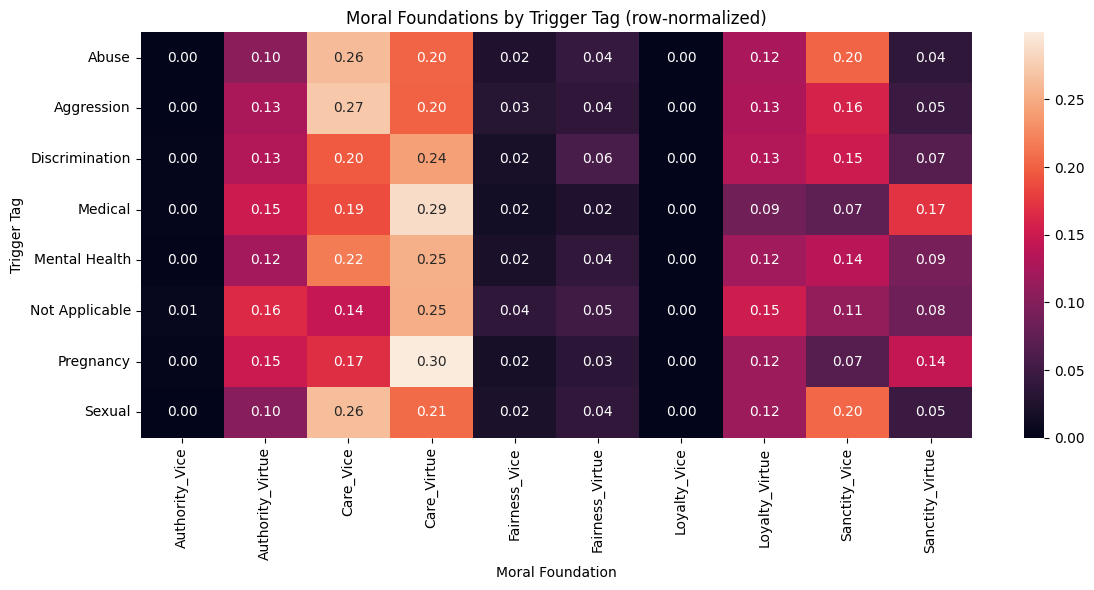

In [44]:
# Heatmap

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.heatmap(pivot_norm, annot=True, fmt=".2f")
plt.title("Moral Foundations by Trigger Tag (row-normalized)")
plt.xlabel("Moral Foundation"); plt.ylabel("Trigger Tag")
plt.tight_layout()
plt.show()


In [45]:
top_per_tag = pivot.apply(lambda r: r.sort_values(ascending=False).head(3), axis=1)
top_per_tag

Moral,Authority_Virtue,Care_Vice,Care_Virtue,Loyalty_Virtue,Sanctity_Vice,Sanctity_Virtue
Tag,,,,,,
Abuse,NaN,1047.0,801.0,NaN,805.0,NaN
Aggression,NaN,130.0,96.0,NaN,76.0,NaN
Discrimination,NaN,247.0,305.0,NaN,189.0,NaN
Medical,NaN,534.0,818.0,NaN,NaN,489.0
Mental Health,NaN,1499.0,1750.0,NaN,937.0,NaN
Not Applicable,280.0,NaN,431.0,258.0,NaN,NaN
Pregnancy,665.0,749.0,1334.0,NaN,NaN,NaN
Sexual,NaN,518.0,406.0,NaN,402.0,NaN


In [46]:
from scipy.stats import chi2_contingency
chi2, p, dof, _ = chi2_contingency(pivot.values)
print("Chi-square:", chi2, "p-value:", p)


Chi-square: 1446.2407491640324 p-value: 1.0228991415140953e-260
